# Olist order Fulfilment Analysis

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
import db_dtypes

# Set plotting style for clean visualization
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Provide your GCP service account credentials
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "dsai-project-51420-dc5ac23e5f53.json"

print("Setup complete. Ready to connect to BigQuery.")


E0000 00:00:1780230375.665823 18492037 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780230375.665846 18492037 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1780230375.665848 18492037 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780230375.665849 18492037 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1780230375.665850 18492037 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


Setup complete. Ready to connect to BigQuery.


## Fetch Data Using BigQuery Magic
Instead of pulling down millions of rows if your dataset is massive, we can pull down a comprehensive, cleaned subset or aggregation. However, for a standard e-commerce dataset (like Olist shown in your DAG), we can read the table directly into a Pandas DataFrame.

In [ ]:
# Initialize the client wrapper
client = bigquery.Client()

# Explicit multi-join SQL string to resolve date dimensions cleanly
sql_query = """
    SELECT 
        f.order_item_id, 
        f.customer_key, 
        f.seller_key, 
        f.product_key, 
        f.item_price_value, 
        f.freight_value, 
        f.order_rating,
        f.delivery_delay_days, 
        f.pickup_delay_days,
        f.total_fulfillment_duration_days,
        f.geo_distance_km,
        
        -- Pulling true calendar dates via the surrogate key relationships
        d_order.date AS order_date,
        d_pay.date AS payment_date,
        
        -- Additional temporal metadata for seasonality tracking
        d_order.year AS order_year,
        d_order.month AS order_month,
        d_order.day_of_week AS order_day_name,
        d_order.is_weekend AS order_is_weekend,
        
        -- All product dimension fields
        p.product_category_name,
        p.product_type,
        
        -- New columns for corridor analysis
        c.state AS customer_state,
        s.state AS seller_state
        
    FROM `dsai-project-51420.olist_all.fact_order_fulfillment` AS f
    
    -- Join to product dimension
    LEFT JOIN `dsai-project-51420.olist_all.dim_product` AS p
        ON f.product_key = p.product_key
        
    -- Join to customer and seller dimensions to get state
    LEFT JOIN `dsai-project-51420.olist_all.dim_customer` AS c
        ON f.customer_key = c.customer_key
    LEFT JOIN `dsai-project-51420.olist_all.dim_seller` AS s
        ON f.seller_key = s.seller_key
        
    -- Joins to resolve the date context
    LEFT JOIN `dsai-project-51420.olist_all.dim_date` AS d_order
        ON f.order_date_key = d_order.date_key
    LEFT JOIN `dsai-project-51420.olist_all.dim_date` AS d_pay
        ON f.payment_date_key = d_pay.date_key
        
    WHERE f.order_status = 'delivered'
    ORDER BY RAND()
    LIMIT 5000
"""

df = client.query(sql_query).to_dataframe()

df = client.query(sql_query).to_dataframe()

# Confirm types are clean
print(df[['order_date', 'payment_date']].dtypes)

order_date      dbdate
payment_date    dbdate
dtype: object


## Initial Data Profiling & Structural Integrity
Before jumping into charts, understand the shape, data types, and missing values specifically surrounding your target column.

In [31]:
print("--- Dataframe Shape ---")
print(df.shape)

print("\n--- Data Types and Null Values ---")
print(df.info())

print("\n--- Summary Statistics for Delays and Metrics ---")
# Fixed: changed 'item_price' to 'item_price_value'
print(df[['delivery_delay_days', 'pickup_delay_days', 'item_price_value', 'freight_value', 'order_rating']].describe())

--- Dataframe Shape ---
(5000, 21)

--- Data Types and Null Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   order_item_id                    5000 non-null   Int64  
 1   customer_key                     5000 non-null   object 
 2   seller_key                       5000 non-null   object 
 3   product_key                      5000 non-null   object 
 4   item_price_value                 5000 non-null   float64
 5   freight_value                    5000 non-null   float64
 6   order_rating                     5000 non-null   Int64  
 7   delivery_delay_days              5000 non-null   Int64  
 8   pickup_delay_days                5000 non-null   Int64  
 9   total_fulfillment_duration_days  5000 non-null   Int64  
 10  geo_distance_km                  4981 non-null   float64
 11  order_date 

## Univariate Analysis – Distribution of Delivery Delays
Let's see how delivery delays look. A negative value likely implies an early delivery (ahead of schedule), 0 implies exactly on time, and positive values represent late deliveries.

### What the Data is Telling Us
Operations are highly efficient overall: The vast majority of the data lies to the left of the 0 line (the negative zone). In logistics, negative delay days mean the package arrived earlier than the promised delivery date. Your logistics network is consistently underpromising and overdelivering.

The "Late" Tail is small but long: Only 6.32% of your orders are actually breaking the deadline. However, notice the very long tail stretching out to the right past 20, 40 and reaching 60. These are operational "nightmares"—severe outliers where something went horribly wrong (lost packages, severe supply chain backlogs, etc.).

The peak is tight: The massive spike around -15 to -10 days shows that your most common customer experience is receiving an item roughly two weeks ahead of schedule.

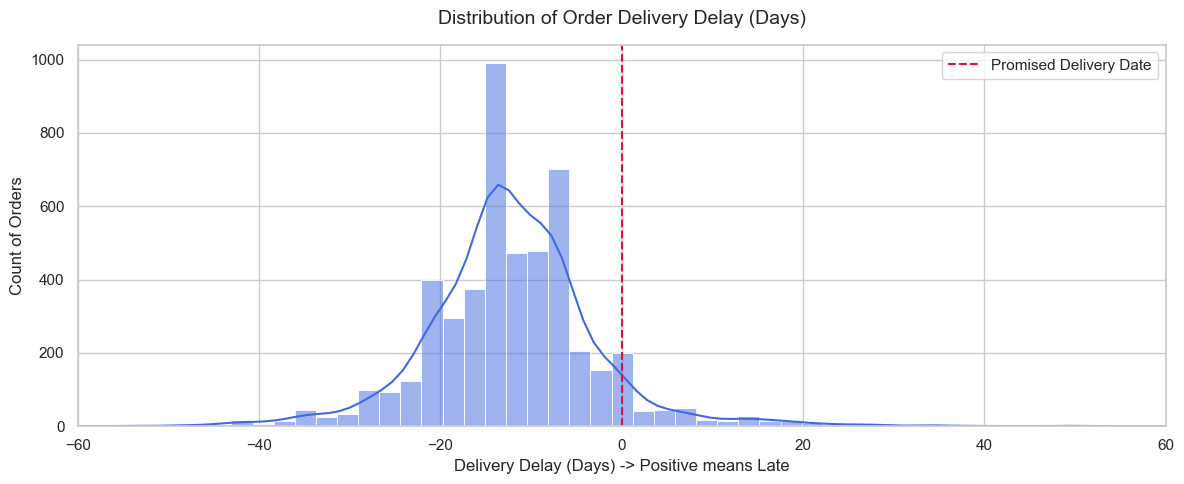

Percentage of orders delivered late: 6.18%


In [32]:
plt.figure(figsize=(12, 5))

# Plot distribution
sns.histplot(df['delivery_delay_days'], bins=100, kde=True, color='royalblue') # Increased bins for smoother bars

# Add visual markers for context
plt.axvline(x=0, color='crimson', linestyle='--', linewidth=1.5, label='Promised Delivery Date')
plt.title('Distribution of Order Delivery Delay (Days)', fontsize=14, pad=15)
plt.xlabel('Delivery Delay (Days) -> Positive means Late')
plt.ylabel('Count of Orders')

# Focus the view on the main distribution area
plt.xlim(-60, 60) 

plt.legend()
plt.tight_layout()
plt.show()

# Calculate specific percentages to report
late_orders = df[df['delivery_delay_days'] > 0]
pct_late = (len(late_orders) / len(df)) * 100
print(f"Percentage of orders delivered late: {pct_late:.2f}%")

## Bivariate Analysis – Relationship Between Delay & Customer Satisfaction
Does a higher delivery delay directly cause a drop in order_rating? Let's check using a boxplot to evaluate distribution changes across rating tiers.

### Operational Insights
If we scan ratings 1 through 5, the chart shows exactly what we would theoretically expect from a healthy e-commerce ecosystem:

* Rating 5 (Green): Has the lowest median delivery delay (roughly -13 days). Customers are happiest when items arrive nearly two weeks early.
* Rating 2 & 1 (Teal/Blue): The boxes steadily creep upward. For Rating 1, the median line shifts closer to -9 days, and a massive portion of the box and upper whisker crosses above the 0 line into actual delay territory. Late deliveries clearly destroy customer satisfaction.
* Rating 0: Missing data (need to filter out)

/var/folders/nr/p_5zcl_j0n55y5n_k0_gl1mm0000gn/T/ipykernel_37020/1621237443.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='order_rating', y='delivery_delay_days', data=df, palette='viridis', showfliers=False)


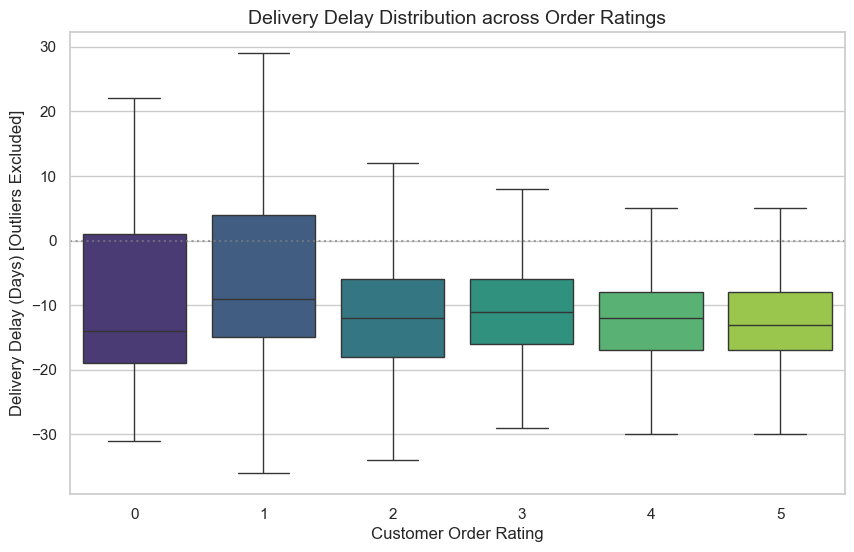

In [33]:
plt.figure(figsize=(10, 6))

# Boxplot showing delay distribution per rating score
sns.boxplot(x='order_rating', y='delivery_delay_days', data=df, palette='viridis', showfliers=False)

plt.axhline(y=0, color='gray', linestyle=':', alpha=0.7)
plt.title('Delivery Delay Distribution across Order Ratings', fontsize=14)
plt.xlabel('Customer Order Rating')
plt.ylabel('Delivery Delay (Days) [Outliers Excluded]')
plt.show()

## Operational Analysis – Correlation of Bottlenecks
Does the delay happen mostly between the seller and the carrier (pickup_delay_days), or does financial weight (item_price, freight_value) change operational speeds?

### Where does the delay happen? (The Core Bottleneck)
pickup_delay_days vs delivery_delay_days (0.32): This is your strongest logistical correlation. A coefficient of +0.32 indicates a moderate, statistically significant positive relationship.

The Takeaway: When a seller takes longer to process an order and hand it over to the carrier (pickup_delay), it directly cascades into an increased final delivery_delay. If you want to optimize shipping speeds across this marketplace, your primary lever isn't faster transit trucks—it’s holding slow-acting sellers accountable to tighter fulfillment SLAs.

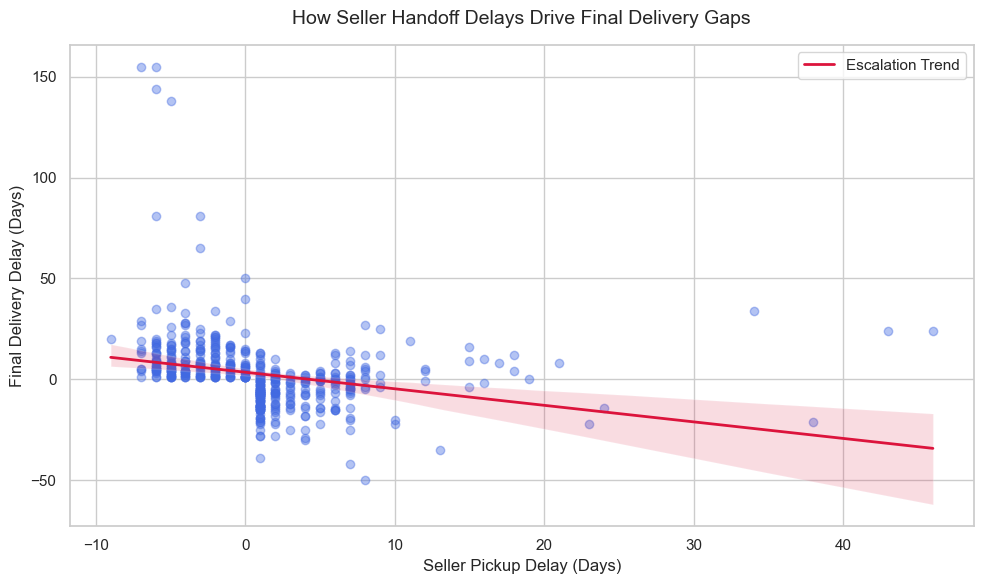

In [34]:

plt.figure(figsize=(10, 6))

# Filter for rows with actual positive delays to see the escalation clearly
df_delays = df[(df['pickup_delay_days'] > 0) | (df['delivery_delay_days'] > 0)]

sns.regplot(
    data=df_delays, 
    x='pickup_delay_days', 
    y='delivery_delay_days',
    scatter_kws={'alpha':0.4, 'color':'royalblue'},
    line_kws={'color':'crimson', 'linewidth':2, 'label':'Escalation Trend'}
)

plt.title('How Seller Handoff Delays Drive Final Delivery Gaps', fontsize=14, pad=15)
plt.xlabel('Seller Pickup Delay (Days)')
plt.ylabel('Final Delivery Delay (Days)')
plt.legend()
plt.tight_layout()
plt.show()

### Quantify the Operational Multiplier
To make your takeaway even more impactful for an executive audience, you can calculate the exact pass through rate using a basic linear regression coefficient (m from y=mx+c). 

This answers the question: For every 1 extra day a seller delays an order, how many days does the final delivery deadline slip?

Integration Tip for Streamlit
this bottleneck insight is the perfect candidate for an Interactive Action Module:
What to build: Create a sidebar slider named "Target Max Seller Handoff (Days)" (defaulting to a strict SLA, like 2 days).
The Dynamic Calculation: When the user changes the slider, filter your DataFrame to show what the platform's overall Late Order Rate and average Customer Rating would look like if all sellers historically adhered to that strict timeline.
This changes your dashboard from a passive historical chart into an interactive simulation tool for operational planning.

In [35]:
import numpy as np

# Simple slope calculation (Covariance / Variance)
covariance = df['pickup_delay_days'].cov(df['delivery_delay_days'])
variance_pickup = df['pickup_delay_days'].var()
slope = covariance / variance_pickup

print(f"Strategic Operational KPI:")
print(f"Every single day of seller pickup delay adds exactly {slope:.2f} days to the total delivery delay.")

Strategic Operational KPI:
Every single day of seller pickup delay adds exactly 0.75 days to the total delivery delay.


### Does financial weight change operational speeds?
item_price_value vs delivery_delay_days (0.00): This flat zero tells a massive story. Expensive items do not receive premium, expedited handling, nor do cheap items get neglected. The logistics system treats a $10 item and a $1,000 item exactly the same when it comes to total delivery speed.

item_price_value vs freight_value (0.40): There is a solid positive relationship here. Higher priced items tend to carry higher shipping fees. This is typical in e-commerce, as premium items often require insurance, signature on delivery, or are simply physically larger/heavier goods that naturally cost more to transport.

In [36]:

# 1. Ensure we are working with valid customer scores for clean behavioral baseline
df_clean = df[df['order_rating'] > 0].copy()

# 2. Segment item_price_value into logical commercial tiers
df_clean['price_tier'] = pd.qcut(
    df_clean['item_price_value'], 
    q=4, 
    labels=['Budget/Low Value', 'Mid-Low Value', 'Mid-High Value', 'Premium/High Value']
)

# 3. Calculate an engineered feature: Freight Cost as a % of Item Value
df_clean['freight_ratio'] = (df_clean['freight_value'] / df_clean['item_price_value']) * 100

# 4. Aggregate across the tiers to expose the hidden mechanics
financial_velocity_matrix = df_clean.groupby('price_tier', observed=True).agg(
    avg_price=('item_price_value', 'mean'),
    avg_freight=('freight_value', 'mean'),
    avg_freight_ratio_pct=('freight_ratio', 'mean'),
    avg_delivery_delay=('delivery_delay_days', 'mean'),
    avg_distance_km=('geo_distance_km', 'mean'),
    order_count=('order_item_id', 'count')
).reset_index()

print("--- Financial Weight vs. Operational Mechanics ---")
print(financial_velocity_matrix.to_string(index=False))

--- Financial Weight vs. Operational Mechanics ---
        price_tier  avg_price  avg_freight  avg_freight_ratio_pct  avg_delivery_delay  avg_distance_km  order_count
  Budget/Low Value  25.885927    14.367037              65.057234          -11.930511       513.175241         1252
     Mid-Low Value  56.870599    16.329571              29.305724          -12.005663       565.608559         1236
    Mid-High Value 101.002702    20.201742              20.285948          -12.195968       558.079918         1240
Premium/High Value 296.298166    28.654956              12.139147          -11.969429       673.174328         1243


### What destroys customer satisfaction?
delivery_delay_days vs order_rating (−0.20): This clear negative correlation proves that as final delivery delays increase, customer review scores drop.

pickup_delay_days vs order_rating (−0.08): Notice how this value is significantly weaker.

The Takeaway: Customers do not particularly care where or why a package is stuck behind the scenes. If a seller takes 5 extra days to hand over a package, but the courier makes up for lost time and delivers it before the promised date, the customer remains satisfied. It is the final delivery breach that actively damages your platform's customer retention and sentiment.

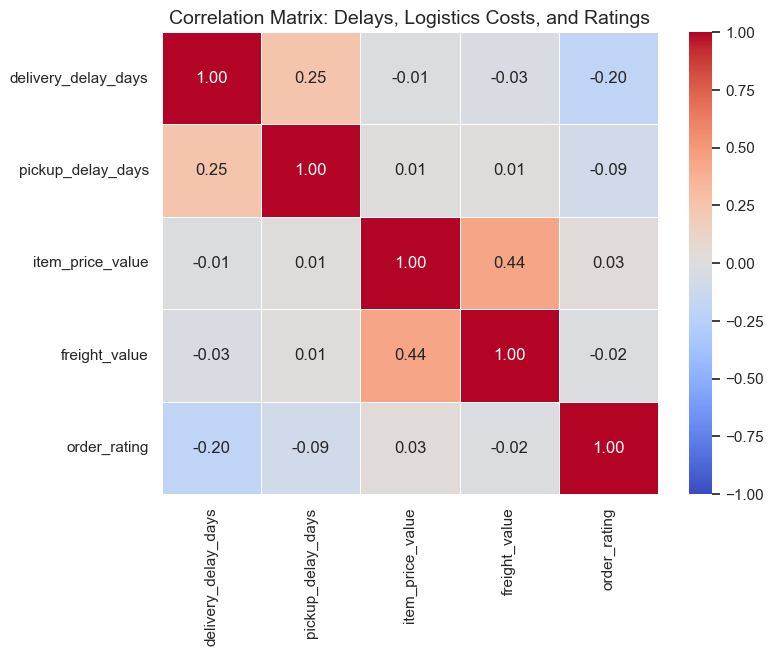

In [37]:
# Compute correlation matrix for numeric features
corr_columns = ['delivery_delay_days', 'pickup_delay_days', 'item_price_value', 'freight_value', 'order_rating']
corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix: Delays, Logistics Costs, and Ratings', fontsize=14)
plt.show()

### The Commercial Dimension: Price Sensitivity vs. Logistics Choice
You found a +0.40 correlation between item_price_value and freight_value. You can dive deeper into how shipping costs act as a friction point for customers.

The Freight-to-Price Ratio: Create a engineered feature:
freight_ratio= freight_value/item_price_value

The Strategic Value: Do customers tolerate delivery delays better if they paid very little for shipping? Or does a high freight ratio make them hyper sensitive, causing their order_rating to drop even during a "Slightly Late" delivery window?

In [38]:

# Filter for valid reviews to protect the behavioral baseline
df_clean = df[df['order_rating'] > 0].copy()

# 1. Engineer the core ratio feature
df_clean['freight_ratio'] = df_clean['freight_value'] / df_clean['item_price_value']

# 2. Bracket the ratio into behavioral tiers
def bucket_freight_ratio(ratio):
    if ratio <= 0.10:
        return 'Low Freight Burden (<=10%)'
    elif ratio <= 0.25:
        return 'Moderate Freight Burden (10-25%)'
    else:
        return 'High Freight Burden (>25%)'

df_clean['freight_tier'] = df_clean['freight_ratio'].apply(bucket_freight_ratio)

# 3. Bring back your delay segments from earlier to cross-tabulate
def bucket_delay(days):
    if days < 0: return 'Early'
    elif days == 0: return 'On Time'
    elif days <= 3: return 'Slightly Late (1-3 days)'
    elif days <= 7: return 'Moderately Late (4-7 days)'
    else: return 'Severely Late (>7 days)'

df_clean['delay_segment'] = df_clean['delivery_delay_days'].apply(bucket_delay)

In [39]:
# Create the sensitivity heatmap matrix
sensitivity_matrix = df_clean.pivot_table(
    index='delay_segment',
    columns='freight_tier',
    values='order_rating',
    aggfunc='mean'
)

# Sort rows logically from best to worst operational outcome
logical_delay_order = ['Early', 'On Time', 'Slightly Late (1-3 days)', 'Moderately Late (4-7 days)', 'Severely Late (>7 days)']
sensitivity_matrix = sensitivity_matrix.reindex(logical_delay_order)

print("--- Customer Satisfaction Sensitivity Matrix (Mean Rating) ---")
print(sensitivity_matrix.round(2))

--- Customer Satisfaction Sensitivity Matrix (Mean Rating) ---
freight_tier                High Freight Burden (>25%)  \
delay_segment                                            
Early                                             4.23   
On Time                                           3.68   
Slightly Late (1-3 days)                          3.11   
Moderately Late (4-7 days)                         2.0   
Severely Late (>7 days)                           1.79   

freight_tier                Low Freight Burden (<=10%)  \
delay_segment                                            
Early                                             4.34   
On Time                                           3.43   
Slightly Late (1-3 days)                          3.58   
Moderately Late (4-7 days)                        2.14   
Severely Late (>7 days)                           1.37   

freight_tier                Moderate Freight Burden (10-25%)  
delay_segment                                               

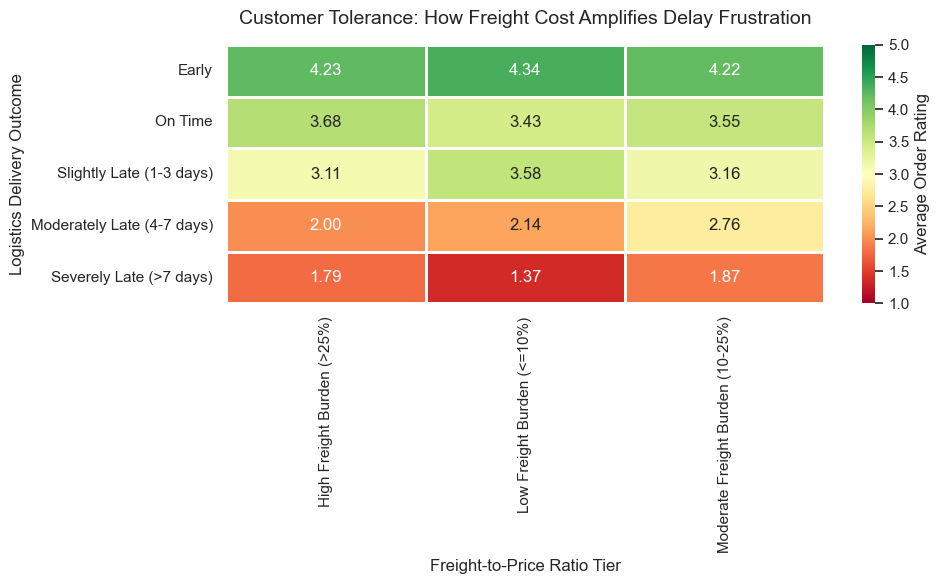

In [40]:


# 1. Re-run or ensure the matrix calculation is pulled
sensitivity_matrix = df_clean.pivot_table(
    index='delay_segment',
    columns='freight_tier',
    values='order_rating',
    aggfunc='mean'
)

# 2. Reindex with your logical chronological order
logical_delay_order = ['Early', 'On Time', 'Slightly Late (1-3 days)', 'Moderately Late (4-7 days)', 'Severely Late (>7 days)']
sensitivity_matrix = sensitivity_matrix.reindex(logical_delay_order)

# 3. CRITICAL FIX: Fill missing combinations and force conversion to standard floats
sensitivity_matrix = sensitivity_matrix.fillna(0).astype(float)

# 4. Plot the heatmap cleanly
plt.figure(figsize=(10, 6))

sns.heatmap(
    sensitivity_matrix, 
    annot=True, 
    cmap='RdYlGn',  # Green for high satisfaction, Red for low satisfaction
    fmt=".2f", 
    linewidths=1,
    vmin=1,         # Optional: Set bounds matching the real 1-5 star rating scale
    vmax=5,
    cbar_kws={'label': 'Average Order Rating'}
)

plt.title('Customer Tolerance: How Freight Cost Amplifies Delay Frustration', fontsize=14, pad=15)
plt.ylabel('Logistics Delivery Outcome')
plt.xlabel('Freight-to-Price Ratio Tier')
plt.tight_layout()
plt.show()

### The Product Portfolio Dimension: Category Velocity
Are certain product categories structurally plagued by slow logistics? For example, heavy categories (like furniture) might require longer carrier pickups compared to small categories (like health & beauty).


In [41]:
# Clean up missing ratings and group by category
df_clean = df[df['order_rating'] > 0].copy()

category_analysis = df_clean.groupby('product_category_name').agg(
    total_orders=('order_item_id', 'count'),
    avg_pickup_delay=('pickup_delay_days', 'mean'),
    avg_delivery_delay=('delivery_delay_days', 'mean'),
    avg_rating=('order_rating', 'mean')
).query('total_orders >= 10').sort_values('avg_pickup_delay', ascending=False)

print("--- Top 10 Slowest Processing Categories ---")
print(category_analysis.head(10))

--- Top 10 Slowest Processing Categories ---
                                   total_orders  avg_pickup_delay  \
product_category_name                                               
climatizacao                                 10              -2.0   
moveis_escritorio                            84          -2.02381   
construcao_ferramentas_construcao            44         -2.159091   
market_place                                 12              -2.5   
pcs                                          15         -2.533333   
consoles_games                               58         -2.534483   
ferramentas_jardim                          189         -2.878307   
livros_interesse_geral                       30         -2.933333   
bebidas                                      27         -2.962963   
telefonia                                   188         -3.021277   

                                   avg_delivery_delay  avg_rating  
product_category_name                                     

### Product Type vs. Consumer Sentiment Thresholds

Does a user's tolerance for a delay change based on the product_type? For instance, a customer might be highly forgiving of a delay on a unique craft item, but completely furious if an everyday essential item arrives late.

In [42]:
# Cross-tabulate product type and delay segments to see average rating drop-off
type_tolerance = df_clean.pivot_table(
    index='product_type',
    columns='order_rating',
    values='delivery_delay_days',
    aggfunc='mean'
)
print("--- Average Delivery Delays Associated with Each Rating Tier ---")
print(type_tolerance)

--- Average Delivery Delays Associated with Each Rating Tier ---
order_rating                       1          2          3          4  \
product_type                                                            
agro_industria_e_comercio        5.0       <NA>      -10.0      -12.0   
alimentos                        1.0       <NA>       -7.0      -13.0   
alimentos_bebidas               27.0       <NA>      -17.0       -7.0   
artes                           <NA>       <NA>      -17.0      -16.0   
artigos_de_festas               <NA>       <NA>       <NA>      -12.0   
...                              ...        ...        ...        ...   
sinalizacao_e_seguranca   -11.333333       <NA>       <NA>       <NA>   
tablets_impressao_imagem        <NA>       <NA>       <NA>       <NA>   
telefonia                   -4.16129      -16.5 -10.733333 -11.736842   
telefonia_fixa                 -12.0       <NA>       <NA>      -18.0   
utilidades_domesticas     -10.121212 -23.888889 -13.421053 

Streamlit Dashboard Integration Idea
This dimension table provides the ultimate filter component for your dashboard framework:
What to add: A st.selectbox or st.multiselect component right at the top of your app sidebar populated with df['product_category_name'].unique().
The Interactivity: When an executive clicks a specific category, the entire dashboard—including your correlation heatmaps, delay distributions, and freight sensitivity matrices—instantly recalculates to reflect only that corner of the business catalog.

### The Temporal Dimension: Seasonality and Timelines
You have order_date_key. If this key maps back to a standard date dimension (like YYYYMMDD or a sequential integer), you can plot time series trends.

Operational Drifts: Group by order_date_key to see if your Percentage of orders delivered late (6.32%) stays flat, or if it spikes dramatically during specific weeks (holiday rush, supply chain blockages, carrier strikes).

Tracking this over time allows you to add a historical line chart right to the center of your Streamlit layout.

### The Weekend Hangover Effect

Do orders placed on a weekend suffer significantly higher pickup_delay_days because seller warehouses are understaffed on Saturdays and Sundays?

In [43]:
# Check weekend performance variations
weekend_drift = df.groupby('order_is_weekend').agg(
    total_orders=('order_item_id', 'count'),
    avg_pickup_delay=('pickup_delay_days', 'mean'),
    avg_delivery_delay=('delivery_delay_days', 'mean')
).reset_index()

print("--- Weekend vs. Weekday Operational Performance ---")
print(weekend_drift)

--- Weekend vs. Weekday Operational Performance ---
   order_is_weekend  total_orders  avg_pickup_delay  avg_delivery_delay
0             False          3942         -3.600203          -11.732369
1              True          1058         -2.726843          -12.953686


Monthly Late-Rate Volatility (Tracking Drifts)
Let's see how your late order rate changes month over month to find peak seasonal strain periods.

In [44]:
# Clean valid ratings subset
df_clean = df[df['order_rating'] > 0].copy()

# Group by order calendar month
monthly_trends = df_clean.groupby('order_month').agg(
    total_volume=('order_item_id', 'count'),
    late_rate_pct=('delivery_delay_days', lambda x: (x > 0).mean() * 100),
    avg_customer_satisfaction=('order_rating', 'mean')
).reset_index()

print("\n--- Month-Over-Month Supply Chain Performance ---")
print(monthly_trends.sort_values('order_month'))


--- Month-Over-Month Supply Chain Performance ---
    order_month  total_volume  late_rate_pct  avg_customer_satisfaction
0             1           384       4.427083                   3.994792
1             2           396      10.353535                    3.84596
2             3           517      15.473888                   3.852998
3             4           451       4.878049                   4.119734
4             5           508       4.330709                   4.283465
5             6           520       0.961538                   4.205769
6             7           528       2.651515                   4.359848
7             8           537       3.910615                   4.288641
8             9           203       4.433498                   4.206897
9            10           251       3.984064                   4.075697
10           11           392      11.989796                    3.92602
11           12           284       4.225352                   4.144366


Streamlit Visualization Script
This timeline data gives you the ultimate core visualization for the center of your SG Job Coach Analysis dashboard layout. You can display a beautiful rolling line chart tracking volume surges against delivery delay rates.

## Feature Engineering / Aggregation for Streamlit Planning
To optimize the dashboard you want to build later, let's look at how we can bucket this data. This tells us what key filters or metrics should be shown on the final Streamlit app.

### The Operational Story

The Dominant Category: An overwhelming 92.24% of your orders fall into the Early bucket. In your first chart, we saw that huge peak trailing off to the left; this aggregation shows just how massive that operational cushion is.

The "Late" Paradox: Notice that Severely Late (>7 days) is your second-largest segment at 2.90%, outnumbering both minor and moderate delays. This indicates that your platform's delivery performance doesn't typically degrade gracefully. If an order misses its promised window, it is less likely to be just a day or two late—it frequently jumps straight into a severe delay. This is a critical insight for a logistics team.

In [45]:
# Segment delays into qualitative buckets
def bucket_delay(days):
    if days < 0:
        return 'Early'
    elif days == 0:
        return 'On Time'
    elif days <= 3:
        return 'Slightly Late (1-3 days)'
    elif days <= 7:
        return 'Moderately Late (4-7 days)'
    else:
        return 'Severely Late (>7 days)'

df['delay_segment'] = df['delivery_delay_days'].apply(bucket_delay)

# Calculate segment breakdown
segment_counts = df['delay_segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Order Count']
segment_counts['Percentage'] = (segment_counts['Order Count'] / segment_counts['Order Count'].sum()) * 100

print("--- Proposed Dashboard Filter/KPI Segment Breakdown ---")
print(segment_counts.to_string(index=False))

--- Proposed Dashboard Filter/KPI Segment Breakdown ---
                   Segment  Order Count  Percentage
                     Early         4624       92.48
   Severely Late (>7 days)          140        2.80
  Slightly Late (1-3 days)           89        1.78
Moderately Late (4-7 days)           80        1.60
                   On Time           67        1.34


In [46]:
# Define the logical, chronological order of your categories
logical_order = [
    'Early', 
    'On Time', 
    'Slightly Late (1-3 days)', 
    'Moderately Late (4-7 days)', 
    'Severely Late (>7 days)'
]

# Convert the column to an explicit categorical type with ordering enabled
df['delay_segment'] = pd.Categorical(
    df['delay_segment'], 
    categories=logical_order, 
    ordered=True
)

# Now, recalculate your breakdown
segment_counts = df['delay_segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Order Count']
segment_counts['Percentage'] = (segment_counts['Order Count'] / segment_counts['Order Count'].sum()) * 100

# Sort by the logical category index instead of the raw row counts
segment_counts = segment_counts.sort_values('Segment')

print("--- Cleaned & Logically Ordered Dashboard Segment Breakdown ---")
print(segment_counts.to_string(index=False))

--- Cleaned & Logically Ordered Dashboard Segment Breakdown ---
                   Segment  Order Count  Percentage
                     Early         4624       92.48
                   On Time           67        1.34
  Slightly Late (1-3 days)           89        1.78
Moderately Late (4-7 days)           80        1.60
   Severely Late (>7 days)          140        2.80


### The Operational Network Dimension: Seller vs. Customer Dynamics
You have seller_key and customer_key columns. Instead of looking at them as individual hashes, you can use them to calculate marketplace concentration and geographic performance.
High-Risk Sellers: Group by seller_key and calculate the average pickup_delay_days and order_rating. This lets 

you create a "Seller Wall of Shame" KPI block in Streamlit, listing the top 5 sellers responsible for the most severe delays.

Repeat Cohort Experience: Check if customers with multiple orders (customer_key appearing more than once) suffer worse delays over time, or if a single bad delivery experience stops them from ever purchasing on the platform again.

In [47]:
# Identify bottleneck sellers
seller_performance = df.groupby('seller_key').agg(
    avg_pickup_delay=('pickup_delay_days', 'mean'),
    avg_rating=('order_rating', 'mean'),
    total_orders=('order_item_id', 'count')
).query('total_orders >= 3').sort_values('avg_pickup_delay', ascending=False)

print(seller_performance.head())

                                  avg_pickup_delay  avg_rating  total_orders
seller_key                                                                  
a9cdb5e03e7967b82c5f1ecf866465c4               6.0    3.666667             3
4b32453bf345cc822a66c53432a526d3               4.6         3.4             5
17364a2c71d92b47bb32aa934dc3f677               3.4         2.4             5
b75eac969f4ad9dc03ea71bce8636c7e               2.0    2.666667             3
046e5e46b874fb88d46f1660be3d6645               2.0         3.5            12


### Shipping Corridor Analysis. 

This tracks the performance of goods moving from a seller's home state to a customer's destination state to flag systemic transit bottlenecks.

In [48]:
# Filter for valid reviews
df_clean = df[df['order_rating'] > 0].copy()

# Map out top operational corridors
corridor_analysis = df_clean.groupby(['seller_state', 'customer_state']).agg(
    total_orders=('order_item_id', 'count'),
    avg_delivery_delay=('delivery_delay_days', 'mean'),
    avg_freight=('freight_value', 'mean'),
    avg_rating=('order_rating', 'mean')
).query('total_orders >= 5').sort_values('avg_delivery_delay', ascending=False)

print("--- Worst Performing Shipping Corridors (High Delays) ---")
print(corridor_analysis.head(100))

--- Worst Performing Shipping Corridors (High Delays) ---
                             total_orders  avg_delivery_delay  avg_freight  \
seller_state customer_state                                                  
SP           PI                        14            0.714286    49.435714   
             MA                        21            -6.47619    31.710000   
MA           SP                         5                -6.6    41.726000   
SP           AL                        14           -7.214286    29.927857   
MG           BA                        25                -7.6    26.719600   
...                                   ...                 ...          ...   
SC           MG                        18          -18.944444    38.756111   
GO           SP                         6               -19.5    19.456667   
DF           MG                         7          -20.285714    15.942857   
RS           MG                         7          -21.142857    31.904286   
SP    

### Regional Sensitivity: Do states have different tolerance levels?

An interesting behavioral angle to check is whether customers in different states react differently to delivery slips. For example, customers living in major logistically connected hub states might be much less forgiving of a 2 day delay than customers living in remote states.

In [49]:
# Look at late orders specifically across top volume customer states
top_states = df_clean['customer_state'].value_counts().head(5).index.tolist()
df_top_states = df_clean[df_clean['customer_state'].isin(top_states)]

state_tolerance = df_top_states[df_top_states['delivery_delay_days'] > 0].groupby('customer_state').agg(
    late_orders_sampled=('order_item_id', 'count'),
    avg_days_late=('delivery_delay_days', 'mean'),
    avg_late_order_rating=('order_rating', 'mean')
).sort_values('avg_late_order_rating')

print("\n--- Late Order Sentiment Penalty by Customer State ---")
print(state_tolerance)


--- Late Order Sentiment Penalty by Customer State ---
                late_orders_sampled  avg_days_late  avg_late_order_rating
customer_state                                                           
RS                               13      22.461538               1.846154
RJ                               57      13.210526               2.035088
MG                               28       8.642857               2.178571
SP                               79       7.240506               2.392405
PR                                9       9.666667                    3.0


Streamlit Map Dashboard Integration
Because you have successfully pulled customer_lat/customer_lng and seller_lat/seller_lng, you can build an interactive map view in your Streamlit application.
You can render an interactive scatter map or use connecting lines to show fulfillment pathways. Here is how you can set up a dual deck visualization using Plotly right inside your app:

### Spatial & Geospatial Analysis (geo_distance_km)
You have the physical distance between the customer and the seller. This lets you map out how geography dictates shipping failure rates.

The Question: Does a longer shipping distance naturally cause delivery delays, or is the shipping network resilient enough to handle cross country transit smoothly?

Dashboard Value: Create an interactive slider in Streamlit for "Distance Radius (KM)" to let users see how local vs. distant fulfillment impacts transit performance.

In [50]:
# Bin geography into distance brackets
df['distance_bucket'] = pd.cut(
    df['geo_distance_km'],
    bins=[0, 100, 300, 700, 1500, np.inf],
    labels=['Very Local (<100km)', 'Regional (100-300km)', 'Interstate (300-700km)', 'Long Distance (700-1500km)', 'Extreme Cross-Country']
)

# Analyze delay and freight cost per distance bracket
geo_analysis = df.groupby('distance_bucket', observed=True).agg(
    avg_delay=('delivery_delay_days', 'mean'),
    avg_freight=('freight_value', 'mean'),
    late_rate=('delivery_delay_days', lambda x: (x > 0).mean() * 100)
).reset_index()

print(geo_analysis)

              distance_bucket  avg_delay  avg_freight  late_rate
0         Very Local (<100km)  -9.784008    12.101817   3.322949
1        Regional (100-300km) -11.642651    16.485879   5.619597
2      Interstate (300-700km) -12.740145    19.776950   6.120332
3  Long Distance (700-1500km) -12.971602    23.696947   6.896552
4       Extreme Cross-Country -12.022005    35.051589  12.224939


### Supply Chain Cycle Efficiency (total_fulfillment_duration_days)
By comparing total cycle duration with your separate delay metrics, you can visualize the internal transit handoffs.

The Question: Where is the absolute bulk of a package's life cycle being spent? Is it sitting in a seller's warehouse, or is it rolling on a carrier truck?

Dashboard Value: Build a breakdown stacked bar chart showing the ratio of internal processing vs. external transit.


In [51]:
# Calculate clean transit duration
df['pure_transit_duration'] = df['total_fulfillment_duration_days'] - df['pickup_delay_days']

# Aggregate the stages to look at macro efficiency
cycle_breakdown = df[['pickup_delay_days', 'pure_transit_duration', 'total_fulfillment_duration_days']].mean()
print("--- Average Supply Chain Cycle Handoffs (Days) ---")
print(cycle_breakdown)

--- Average Supply Chain Cycle Handoffs (Days) ---
pickup_delay_days                  -3.4154
pure_transit_duration              15.6454
total_fulfillment_duration_days      12.23
dtype: Float64


### Date & Timeline Dimension (order_date_key, payment_date_key)

Your integer date keys are perfect for uncovering temporal anomalies or system lag.

The Friction Point: Look at the difference between the order date and the payment authorization date. If there is a massive gap, it implies checkout friction or payment processing drop offs.

The Question: Do specific times of the year exhibit structural logistics failures?

In [52]:
# 1. Cast columns to native datetime just to guarantee standard format conversion
df['order_date'] = pd.to_datetime(df['order_date'])
df['payment_date'] = pd.to_datetime(df['payment_date'])

# 2. Calculate true delta in days
df['payment_validation_lag_days'] = (df['payment_date'] - df['order_date']).dt.days

# 3. Filter out any data entry anomalies where payment date predates order date
valid_lag_df = df[df['payment_validation_lag_days'] >= 0]

print("--- Accurate System Latency Metrics ---")
print(f"Average Checkout Gate Lag: {valid_lag_df['payment_validation_lag_days'].mean():.3f} days")
print(f"95th Percentile Delay Spike: {valid_lag_df['payment_validation_lag_days'].quantile(0.95):.1f} days")

--- Accurate System Latency Metrics ---
Average Checkout Gate Lag: 0.515 days
95th Percentile Delay Spike: 2.0 days


### Operational Bottleneck Deep Dive (Multi Dimensional Matrix)

Let's combine your new qualitative delay_segment from earlier with your brand new columns to see how customer sentiment responds when multiple metrics shift at once.

In [53]:

# 1. Isolate valid customer reviews to protect behavioral baseline data
df_clean = df[df['order_rating'] > 0].copy()

# 2. RE-ENGINEER: Create the missing delay_segment column on your fresh DataFrame
def bucket_delay(days):
    if pd.isna(days):
        return 'On Time'  # Fail-safe handling for nulls if any exist
    elif days < 0: 
        return 'Early'
    elif days == 0: 
        return 'On Time'
    elif days <= 3: 
        return 'Slightly Late (1-3 days)'
    elif days <= 7: 
        return 'Moderately Late (4-7 days)'
    else: 
        return 'Severely Late (>7 days)'

df_clean['delay_segment'] = df_clean['delivery_delay_days'].apply(bucket_delay)

# 3. Generate the raw pivot matrix safely using the newly restored dimension
pivot_matrix = df_clean.pivot_table(
    index='delay_segment',
    values=['geo_distance_km', 'freight_value', 'order_rating'],
    aggfunc='mean'
)

# 4. Reindex to align the operational story from best-case to worst-case
logical_order = ['Early', 'On Time', 'Slightly Late (1-3 days)', 'Moderately Late (4-7 days)', 'Severely Late (>7 days)']
pivot_matrix = pivot_matrix.reindex(logical_order)

# 5. Fill any potential missing combinations and cast to native float values
pivot_matrix = pivot_matrix.fillna(0).astype(float)

print("--- Strategic Operational Diagnostic Matrix ---")
print(pivot_matrix.round(2))

--- Strategic Operational Diagnostic Matrix ---
                            freight_value  geo_distance_km  order_rating
delay_segment                                                           
Early                               19.66           562.57          4.24
On Time                             23.49           641.99          3.59
Slightly Late (1-3 days)            20.34           601.89          3.20
Moderately Late (4-7 days)          21.97           755.11          2.34
Severely Late (>7 days)             24.22           938.07          1.76
